# Random Forest

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement du dataset

In [2]:
df = pd.read_csv('dataset_stress_hydrique.csv')
print("Dataset chargé :", df.shape)
print(df['label'].value_counts())

Dataset chargé : (166, 6)
label
Stress_modere    52
Stress_severe    47
Stress_leger     41
Normal           26
Name: count, dtype: int64


## Préparation features et labels

In [4]:
# Les features (entrées du modèle)
X = df[['NDVI', 'NDWI', 'MSI']]

# Les labels (ce qu'on veut prédire)
y = df['label']

# Split train/test 80/20
# random_state=42 : fixe le hasard → résultats reproductibles
# stratify=y : garde les proportions de classes dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille train :", X_train.shape)
print("Taille test  :", X_test.shape)
print("\nDistribution train :")
print(y_train.value_counts())

Taille train : (132, 3)
Taille test  : (34, 3)

Distribution train :
label
Stress_modere    41
Stress_severe    37
Stress_leger     33
Normal           21
Name: count, dtype: int64


## Entraînement du modèle

In [5]:
# n_estimators=100 : 100 arbres dans la forêt
# random_state=42  : reproductibilité
modele = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraînement
modele.fit(X_train, y_train)

print("✅ Modèle entraîné sur", X_train.shape[0], "lignes")

✅ Modèle entraîné sur 132 lignes


##  Évaluation

=== Rapport de classification ===
               precision    recall  f1-score   support

       Normal       1.00      0.80      0.89         5
 Stress_leger       0.89      1.00      0.94         8
Stress_modere       1.00      1.00      1.00        11
Stress_severe       1.00      1.00      1.00        10

     accuracy                           0.97        34
    macro avg       0.97      0.95      0.96        34
 weighted avg       0.97      0.97      0.97        34

=== Matrice de confusion ===


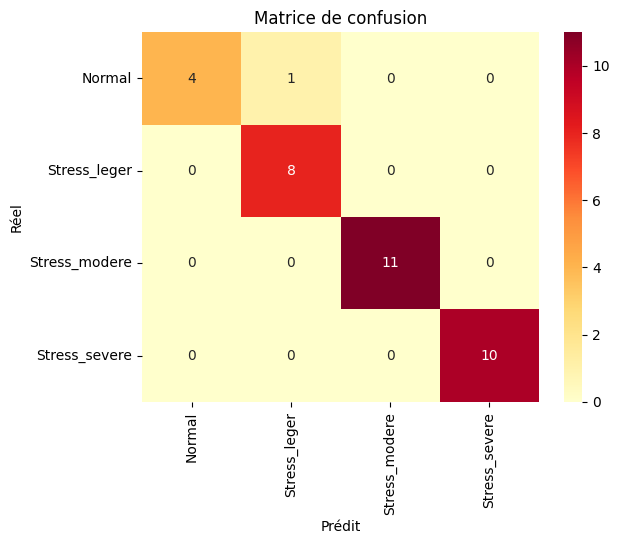

In [7]:
y_pred = modele.predict(X_test)

print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred))

print("=== Matrice de confusion ===")
cm = confusion_matrix(y_test, y_pred, labels=modele.classes_)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=modele.classes_,
            yticklabels=modele.classes_,
            cmap='YlOrRd')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion')
plt.savefig('confusion_matrix.png')
plt.show()